In [1]:

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.feature_selection import VarianceThreshold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from xgboost import XGBRegressor as xgb


import matplotlib.pyplot as plt


In [2]:
%run ./ml_model_init.ipynb

## Data


In [ ]:

cs_data= data[(data['minutes_5'] >= 300) & (data['position'] != 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'was_home', 'clean_sheets',
                                                                        'clean_sheets_3', 'clean_sheets_5', 'expected_goals_conceded_3', 'expected_goals_conceded_5', 'ict_index_3',
                                                                        'ict_index_5', 'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5', 'whh',
                                                                         'whd', 'wha']]



cs_data_tar = data_tar[(data_tar['minutes_5'] >= 300) & (data_tar['position'] != 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'was_home',
                                                                                        'clean_sheets', 'clean_sheets_3', 'clean_sheets_5', 'expected_goals_conceded_3',
                                                                                        'expected_goals_conceded_5', 'ict_index_3', 'ict_index_5', 'influence_3', 'influence_5',
                                                                                        'creativity_3', 'creativity_5', 'threat_3', 'threat_5', 'whh', 'whd', 'wha']]

In [4]:
cs_data = cs_data.dropna()
cs = cs_data[['clean_sheets']]
feats = cs_data.drop('clean_sheets', axis=1)
# print(feats.shape, cs.shape)
feats.drop(['position'], axis=1)

# position = feats['position']
OHE = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = OHE.fit_transform(feats[['position', 'was_home']])
# print(OHE.categories_)

one_hot_df = pd.DataFrame(encoded,  columns=OHE.get_feature_names_out(['position', 'was_home']))

feats_ = feats.drop(['position', 'was_home'], axis=1).reset_index().drop('index', axis=1)

feats_sklearn_encoded = pd.concat([feats_, one_hot_df], axis=1)
# feats_sklearn_encoded

scaler = StandardScaler()

scaled = scaler.fit_transform(feats_sklearn_encoded)
feats_sklearn_enc_scaled = pd.DataFrame(scaled, columns=[feats_sklearn_encoded.columns])



In [6]:
# feats = feats[feats['position'].notnull()]
feats_train, feats_test, cs_train, cs_test = train_test_split(feats_sklearn_enc_scaled, cs , test_size=0.2, random_state=42)


## Baseline Model


#### Linear Model


In [7]:

lin_reg = Linear_regression(feats_train, feats_test, cs_train, cs_test)

# Store the model evaluation details in a DataFrame
evaluation_stats = pd.DataFrame({"lin_reg": [lin_reg['train_MAE'], lin_reg['test_MAE'], lin_reg['train_RMSE'], lin_reg['test_RMSE'], lin_reg['cv_rmse'], lin_reg['R2_train'], lin_reg['R2_test']]},
                                                        index=(['train_MAE','test_MAE', 'train_RMSE', 'test_RMSE', 'cv_rmse', 'R2_train', 'R2_test']))

evaluation_stats

Training set RMSE: 0.41547323324888435
Test set RMSE: 0.41959164077387734
Training set R2: 0.028816955499100794
Test set R2: 0.024051181509177733


,lin_reg
train_MAE,0.345414
test_MAE,0.348591
train_RMSE,0.415473
test_RMSE,0.419592
cv_rmse,0.416616
R2_train,0.028817
R2_test,0.024051


#### DecisionTree Model


In [8]:
dt_reg = DecisionTreeRegression(feats_train, feats_test, cs_train, cs_test)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(dt_reg = [dt_reg['train_MAE'], dt_reg['test_MAE'], dt_reg['train_RMSE'], dt_reg['test_RMSE'], dt_reg['cv_rmse'], dt_reg['R2_train'], dt_reg['R2_test']])

evaluation_stats



,lin_reg,dt_reg
train_MAE,0.345414,0.000000
test_MAE,0.348591,0.219402
train_RMSE,0.415473,0.000000
test_RMSE,0.419592,0.468403
cv_rmse,0.416616,0.480600
R2_train,0.028817,1.000000
R2_test,0.024051,-0.216223


#### RandomForest Model


In [9]:
hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}
rf_reg = RandomForestRegression(feats_train, feats_test, cs_train.values.ravel(), cs_test.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(rf_reg = [rf_reg['train_MAE'], rf_reg['test_MAE'], rf_reg['train_RMSE'], rf_reg['test_RMSE'], rf_reg['cv_rmse'], rf_reg['R2_train'], rf_reg['R2_test']])

evaluation_stats

KeyboardInterrupt: 

#### XgBoost Model


In [ ]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
xgb_reg = XGBoostRegression(feats_train, feats_test, cs_train, cs_test, hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(xgb_reg = [xgb_reg['train_MAE'], xgb_reg['test_MAE'], xgb_reg['train_RMSE'], xgb_reg['test_RMSE'], xgb_reg['cv_rmse'], xgb_reg['R2_train'], xgb_reg['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg
train_MAE,0.075869,5.720813e-20,0.068064,0.073193
test_MAE,0.078375,1.043064e-01,0.079319,0.078653
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402
R2_train,0.153840,1.000000e+00,0.380244,0.239311
R2_test,0.176158,-6.401555e-01,0.174827,0.182850


### AdaBoost


In [ ]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
ada_reg = XGBoostRegression(feats_train, feats_test, cs_train, cs_test, hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(ada_reg = [ada_reg['train_MAE'], ada_reg['test_MAE'], ada_reg['train_RMSE'], ada_reg['test_RMSE'], ada_reg['cv_rmse'], ada_reg['R2_train'], ada_reg['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850


# Feature engineering


### Data


In [10]:
cols_ = ['expected_assists', 'position', 'team_h_difficulty', 'team_a_difficulty', 'value', 'was_home', 'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3', 'xP_3', 'selected_3', 'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5', 'xP_5', 'selected_5', 'whh', 'whd', 'wha']

working_data = data[cols_]
working_data = working_data.fillna(0)
working_data = working_data[working_data['position'] !=0]
working_data


,expected_assists,position,team_h_difficulty,team_a_difficulty,value,was_home,clean_sheets_3,expected_assists_3,expected_goal_involvements_3,expected_goals_3,...,key_passes_5,npg_5,npxG_5,xGChain_5,xGBuildup_5,xP_5,selected_5,whh,whd,wha
0,0.10,DEF,5.0,3.0,5.0,True,0.0,0.00,0.00,0.00,...,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.105,0.188,0.707
1,0.21,DEF,2.0,2.0,5.0,False,0.0,0.10,0.10,0.00,...,1.0,0.0,0.00,0.00,0.00,1.3,266706.0,0.224,0.268,0.508
2,0.33,DEF,3.0,3.0,5.0,True,0.0,0.31,0.36,0.05,...,6.0,0.0,0.05,0.33,0.29,3.3,587596.0,0.419,0.277,0.304
3,0.01,DEF,2.0,2.0,5.0,False,0.0,0.64,0.74,0.10,...,8.0,0.0,0.12,0.40,0.35,4.3,894938.0,0.419,0.277,0.304
4,0.01,DEF,3.0,3.0,4.9,True,1.0,0.55,0.70,0.15,...,8.0,0.0,0.18,0.46,0.42,6.5,1152571.0,0.255,0.262,0.483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8824,0.03,MID,2.0,3.0,7.8,False,1.0,0.96,2.79,1.83,...,13.0,2.0,1.44,5.51,1.98,25.3,16957336.0,0.464,0.264,0.272
8825,0.37,MID,3.0,3.0,7.9,True,0.0,0.51,2.19,1.68,...,13.0,2.0,2.17,6.09,2.01,27.5,17470889.0,0.449,0.236,0.315
8826,0.25,MID,2.0,2.0,7.9,False,0.0,0.52,2.11,1.59,...,13.0,1.0,2.26,6.43,2.21,25.2,18297047.0,0.393,0.270,0.337
8827,0.25,MID,2.0,2.0,7.9,False,0.0,0.52,2.11,1.59,...,13.0,1.0,2.26,6.43,2.21,25.2,18297047.0,0.393,0.270,0.337


In [11]:
xa_data_ = working_data[(working_data['minutes_5'] >= 300) & (working_data['position'] != 'GK')]
xa_data_ = xa_data_.dropna()


# position = feats['position']
OHE_ = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_ = OHE_.fit_transform(xa_data_[['position', 'was_home']])
# print(OHE_.categories_)

one_hot_df = pd.DataFrame(encoded_,  columns=OHE_.get_feature_names_out(['position', 'was_home']))

feats__ = xa_data_.drop(['position', 'was_home'], axis=1).reset_index().drop('index', axis=1)


# Separate numerical features (excluding 'position' before encoding)
scaler = StandardScaler()

scaled = scaler.fit_transform(feats__)
feats_sklearn_enc_scaled_ = pd.DataFrame(scaled, columns=scaler.get_feature_names_out(feats__.columns))
# feats_sklearn_enc_scaled_

# Concatenate scaled numerical features with the one-hot encoded position features
feats_sklearn_enc_scaled_ = pd.concat([feats_sklearn_enc_scaled_, one_hot_df], axis=1)

xa_ = feats_sklearn_enc_scaled_[['expected_assists']]
feats__ = feats_sklearn_enc_scaled_.drop('expected_assists', axis=1)

In [12]:
# feats = feats[feats['position'].notnull()]
feats_train_, feats_test_, train, test = train_test_split(feats__, xa_ , test_size=0.2, random_state=42)

## SelectFromModel


In [13]:
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor as xgb
from sklearn.feature_selection import SelectFromModel

rf_hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}
xg_hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
print(feats_train.shape)
lin_model = LinearRegression()
dt_model = DecisionTreeRegressor()
extr_model = ExtraTreesRegressor(random_state=18)
rf_model = RandomForestRegressor(random_state=18)
xg_model = model = xgb(learning_rate=xg_hyperparameters["learning_rate"],
                    n_estimators=xg_hyperparameters["n_estimators"],
                    max_depth=xg_hyperparameters["max_depth"],
                    eval_metric='rmsle')

ada_model = AdaBoostRegressor(random_state=18)


lin_model = lin_model.fit(feats_train_, train.values.ravel())
dt_model = dt_model.fit(feats_train_, train.values.ravel())
extr_model = extr_model.fit(feats_train_, train.values.ravel())
rf_model = rf_model.fit(feats_train_, train.values.ravel())
xg_model = xg_model.fit(feats_train_, train.values.ravel())
ada_model = ada_model.fit(feats_train_, train.values.ravel())

lin_selector = SelectFromModel(lin_model ,prefit=True)
dt_selector = SelectFromModel(dt_model ,prefit=True)
extr_selector = SelectFromModel(extr_model ,prefit=True)
rf_selector = SelectFromModel(rf_model,prefit=True)
xg_selector = SelectFromModel(xg_model ,prefit=True)
ada_selector = SelectFromModel(ada_model ,prefit=True)


(8824, 24)


KeyboardInterrupt: 

In [ ]:

SelectFromModel_cols_lin = list(feats_train_.columns[lin_selector.get_support()])
SelectFromModel_cols_dt = list(feats_train_.columns[dt_selector.get_support()])
SelectFromModel_cols_rf = list(feats_train_.columns[rf_selector.get_support()])
SelectFromModel_cols_extr = list(feats_train_.columns[extr_selector.get_support()])
SelectFromModel_cols_xg = list(feats_train_.columns[xg_selector.get_support()])
SelectFromModel_cols_ada = list(feats_train_.columns[ada_selector.get_support()])

feats_train_SFM_lin, feats_test_SFM_lin, train_SFM_lin, test_SFM_lin = train_test_split(feats__[SelectFromModel_cols_lin], xa_ , test_size=0.2, random_state=42)
feats_train_SFM_dt, feats_test_SFM_dt, train_SFM_dt, test_SFM_dt = train_test_split(feats__[SelectFromModel_cols_dt], xa_ , test_size=0.2, random_state=42)
feats_train_SFM_rf, feats_test_SFM_rf, train_SFM_rf, test_SFM_rf = train_test_split(feats__[SelectFromModel_cols_rf], xa_ , test_size=0.2, random_state=42)
feats_train_SFM_extr, feats_test_SFM_extr, train_SFM_extr, test_SFM_extr = train_test_split(feats__[SelectFromModel_cols_extr], xa_ , test_size=0.2, random_state=42)
feats_train_SFM_xg, feats_test_SFM_xg, train_SFM_xg, test_SFM_xg = train_test_split(feats__[SelectFromModel_cols_xg], xa_ , test_size=0.2, random_state=42)
feats_train_SFM_ada, feats_test_SFM_ada, train_SFM_ada, test_SFM_ada = train_test_split(feats__[SelectFromModel_cols_ada], xa_ , test_size=0.2, random_state=42)


#### Feature Importance


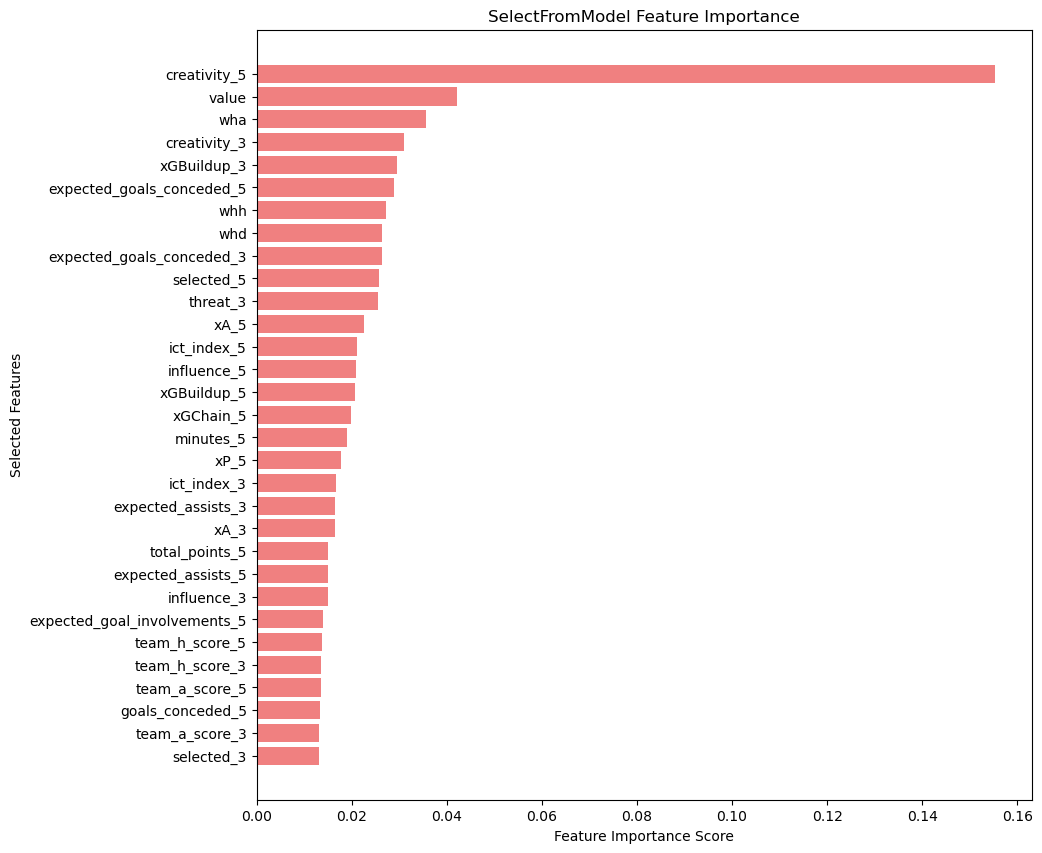

In [ ]:
# Feature selection using SelectFromModel
selected_features_mask = dt_selector.get_support()
selected_feature_names = feats__.columns[selected_features_mask]

# Get feature importances
feature_importances = dt_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()


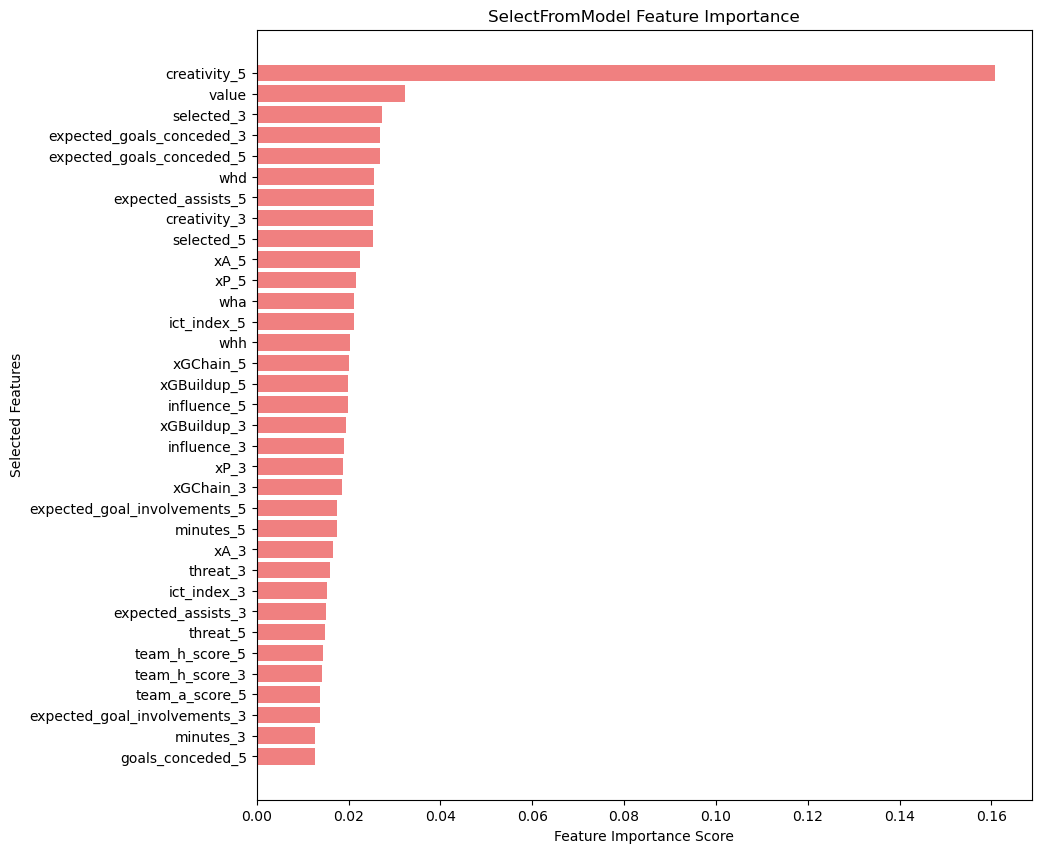

In [ ]:
# Feature selection using SelectFromModel
selected_features_mask = rf_selector.get_support()
selected_feature_names = feats__.columns[selected_features_mask]

# Get feature importances
feature_importances = rf_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

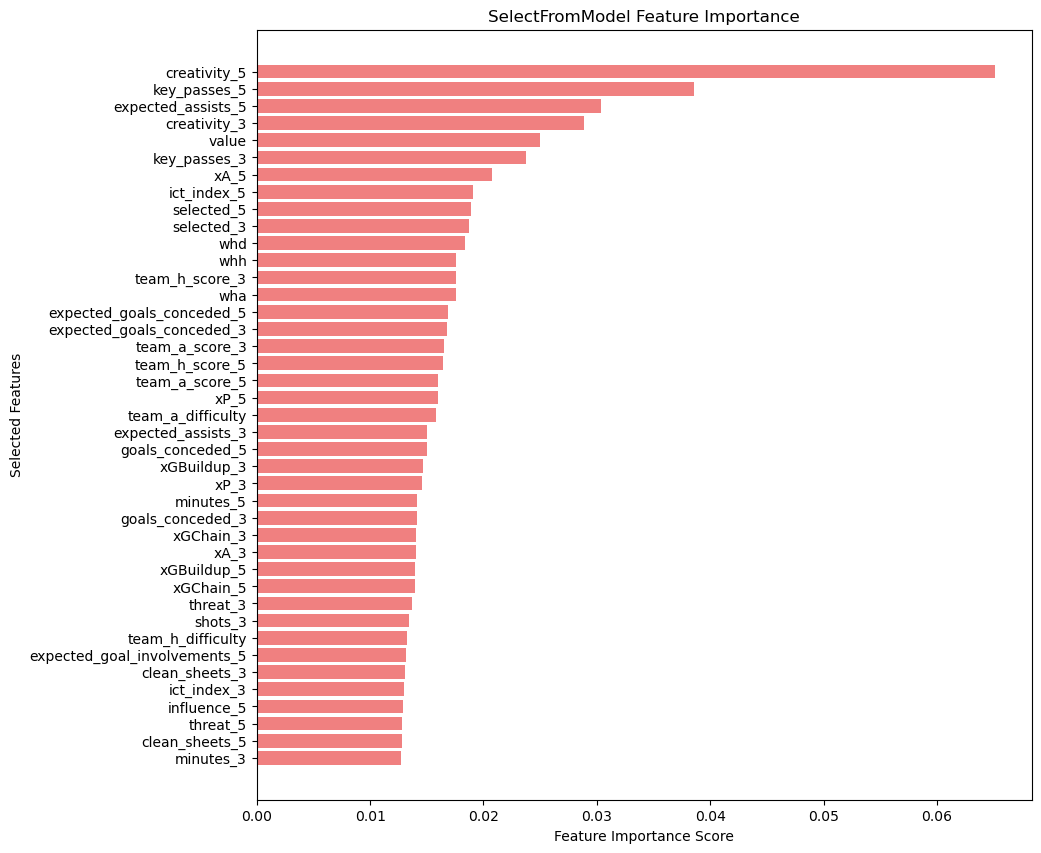

In [ ]:
# Feature selection using SelectFromModel
selected_features_mask = extr_selector.get_support()
selected_feature_names = feats__.columns[selected_features_mask]

# Get feature importances
feature_importances = extr_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

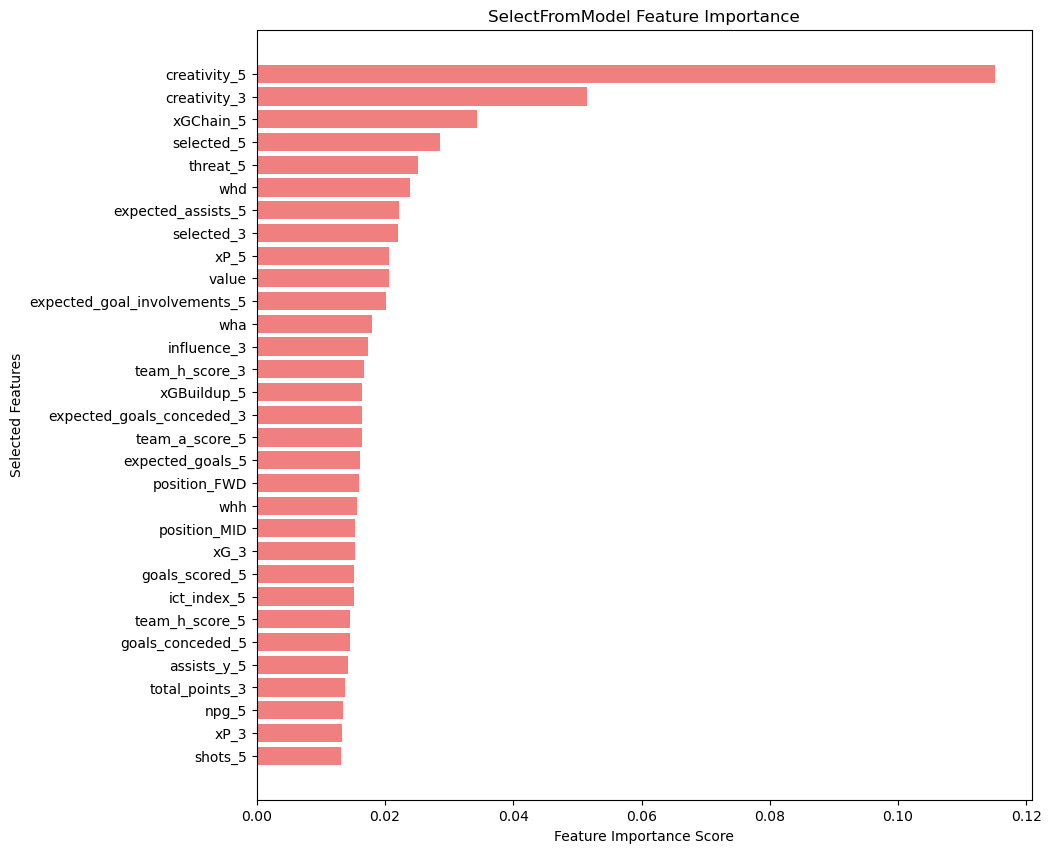

In [ ]:
# Feature selection using SelectFromModel
selected_features_mask = xg_selector.get_support()
selected_feature_names = feats__.columns[selected_features_mask]

# Get feature importances
feature_importances = xg_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

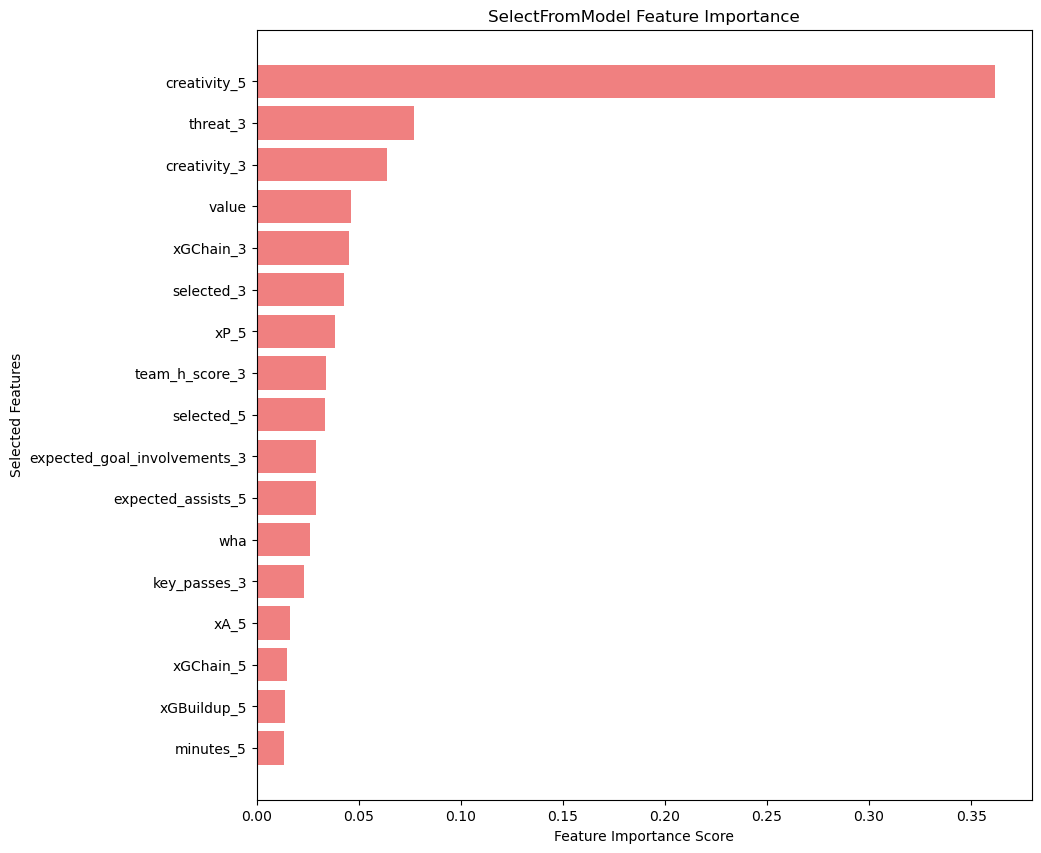

In [ ]:
# Feature selection using SelectFromModel
selected_features_mask = ada_selector.get_support()
selected_feature_names = feats__.columns[selected_features_mask]

# Get feature importances
feature_importances = ada_model.feature_importances_[selected_features_mask]

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending
sorted_features = np.array(selected_feature_names)[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 10))
plt.barh(sorted_features, sorted_importances, color='lightcoral')
plt.xlabel("Feature Importance Score")
plt.ylabel("Selected Features")
plt.title("SelectFromModel Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

#### Linear Model


In [ ]:

lin_reg_SFM = Linear_regression(feats_train_SFM_lin, feats_test_SFM_lin, train_SFM_lin, test_SFM_lin)

# lin_reg_SFM
# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(lin_reg_SFM = [lin_reg_SFM['train_MAE'], lin_reg_SFM['test_MAE'], lin_reg_SFM['train_RMSE'], lin_reg_SFM['test_RMSE'], lin_reg_SFM['cv_rmse'], lin_reg_SFM['R2_train'], lin_reg_SFM['R2_test']])
evaluation_stats

Training set RMSE: 0.949956375973095
Test set RMSE: 1.0450605354562872
Training set R2: 0.05757088553051648
Test set R2: 0.06357457436432035


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575


#### DecisionTree Model


In [ ]:
dt_reg_SFM = DecisionTreeRegression(feats_train_SFM_dt, feats_test_SFM_dt, train_SFM_dt, test_SFM_dt)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(dt_reg_SFM = [dt_reg_SFM['train_MAE'], dt_reg_SFM['test_MAE'], dt_reg_SFM['train_RMSE'], dt_reg_SFM['test_RMSE'], dt_reg_SFM['cv_rmse'], dt_reg_SFM['R2_train'], dt_reg_SFM['R2_test']])

evaluation_stats



,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01


### RandomForest


In [ ]:
hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}
rf_reg_SFM = RandomForestRegression(feats_train_SFM_rf, feats_test_SFM_rf, train_SFM_rf.values.ravel(), test_SFM_rf.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(rf_reg_SFM = [rf_reg_SFM['train_MAE'], rf_reg_SFM['test_MAE'], rf_reg_SFM['train_RMSE'], rf_reg_SFM['test_RMSE'], rf_reg_SFM['cv_rmse'], rf_reg_SFM['R2_train'], rf_reg_SFM['R2_test']])

evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM
train_MAE,0.075869,5.720813e-20,0.068064,0.073193,0.073193,0.608152,1.006006e-17,0.495011
test_MAE,0.078375,1.043064e-01,0.079319,0.078653,0.078653,0.647553,7.874401e-01,0.599778
train_RMSE,0.123292,6.077315e-19,0.105516,0.116899,0.116899,0.949956,4.481411e-17,0.764830
test_RMSE,0.128990,1.820021e-01,0.129094,0.128465,0.128465,1.045061,1.353232e+00,0.995264
cv_rmse,0.123537,1.805701e-01,0.125535,0.123402,0.123402,0.950029,1.318233e+00,0.913620
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098
R2_test,0.176158,-6.401555e-01,0.174827,0.182850,0.182850,0.063575,-5.701275e-01,0.150689


### XgBoost


In [ ]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
xgb_reg_SFM = XGBoostRegression(feats_train_SFM_xg, feats_test_SFM_xg, train_SFM_xg.values.ravel(), test_SFM_xg.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(xgb_reg_SFM = [xgb_reg_SFM['train_MAE'], xgb_reg_SFM['test_MAE'], xgb_reg_SFM['train_RMSE'], xgb_reg_SFM['test_RMSE'], xgb_reg_SFM['cv_rmse'], xgb_reg_SFM['R2_train'], xgb_reg_SFM['R2_test']])
evaluation_stats

### AdaBoost


In [ ]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
ada_reg_SFM = XGBoostRegression(feats_train_SFM_ada, feats_test_SFM_ada, train_SFM_ada.values.ravel(), test_SFM_ada.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(ada_reg_SFM = [ada_reg_SFM['train_MAE'], ada_reg_SFM['test_MAE'], ada_reg_SFM['train_RMSE'], ada_reg_SFM['test_RMSE'], ada_reg_SFM['cv_rmse'], ada_reg_SFM['R2_train'], ada_reg_SFM['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM
train_MAE,0.075869,5.563540e-20,0.068064,0.073193,0.073193,0.608152,9.751088e-18,0.495011,0.530413,0.533870
test_MAE,0.078375,1.053354e-01,0.079319,0.078653,0.078653,0.647553,7.635004e-01,0.599778,0.603198,0.604090
train_RMSE,0.123292,6.155375e-19,0.105516,0.116899,0.116899,0.949956,4.339659e-17,0.764830,0.840290,0.847263
test_RMSE,0.128990,1.829970e-01,0.129094,0.128465,0.128465,1.045061,1.330837e+00,0.995264,0.996281,0.995224
cv_rmse,0.123537,1.829282e-01,0.125535,0.123402,0.123402,0.950029,1.341771e+00,0.913620,0.894712,0.899739
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317
R2_test,0.176158,-6.581365e-01,0.174827,0.182850,0.182850,0.063575,-5.185887e-01,0.150689,0.148953,0.150757


## VarianceThreshold


## Model(VT)


In [ ]:
from sklearn.compose import TransformedTargetRegressor, ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import pandas as pd

# Feature preprocessing pipeline
# Split into numerical and categorical columns
bool_cols = feats_train_.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = feats_train_.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing for numerical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors in a column transformer
col_trans = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, bool_cols),
        ('cat', categorical_transformer, categorical_cols),
    ]
)

# Scale and remove low-variance features
preprocessor = Pipeline(steps=[
    # ('col_trans', col_trans),
    ('var_threshold', VarianceThreshold(threshold=0.1))
])




In [ ]:
def scores(model, feats_train, feats_test, train, test):
    # fit the transofrmer on the train data
    model.fit(feats_train, train)

    # support = model.regressor_.named_steps['preprocessor'].named_steps['var_threshold'].get_support()
    # # print(f"Selected features: {feats_train.columns[support]}")
    # print(len(support), len(feats_train.columns))

    # With the model fitted, we can predict the total_points given the feature_train and feature_test set
    pred_train = model.predict(feats_train)
    pred_test = model.predict(feats_test)

    # Evaluate the performance of the model on both sets using the mean absolute error
    train_MAE = mean_absolute_error(train, pred_train)
    test_MAE = mean_absolute_error(test, pred_test)

    # Evaluate the performance of the model on both sets using the mean square error
    train_MSE = mean_squared_error(train, pred_train)
    test_MSE = mean_squared_error(test, pred_test)

    # Evaluate the performance of the model on both sets using the root mean square error
    train_RMSE = root_mean_squared_error(train, pred_train)
    test_RMSE = root_mean_squared_error(test, pred_test)

    # Get the score of the model or the coeeficient of determination i.e how much of the target value can be explained by the model.
    # In this case, 0.6 implies that 60% of the variations in the target value can be explained by the model and 40% is not explainable
    R2_train = model.score(feats_train, train)
    R2_test = model.score(feats_test, test)

    # If the test error significantly differs from the train error, then there is either overfitting or underfitting
    # RMSE, just like the squared loss function that it derives from, effectively penalizes larger errors more severely.
    print('Training set RMSE: {}'.format(train_RMSE))
    print('Test set RMSE: {}'.format(test_RMSE))

    print('Training set R2: {}'.format(R2_train))
    print('Test set R2: {}'.format(R2_test))

    # Carry out cross validation of the model.
    # The evaluation method is the root mean square error
    # The method expects a utility function (greater is better) and so the scoring function is the opposite of the the RMSE. Hence the -ve
    tree_rmses = -cross_val_score(model, feats_train, train,
                                    scoring="neg_root_mean_squared_error", cv=10)

    return {'train_MAE': train_MAE, 'test_MAE': test_MAE, 'train_MSE': train_MSE, 'test_MSE': test_MSE, 'train_RMSE': train_RMSE, 'test_RMSE': test_RMSE, 'cv_rmse': tree_rmses.mean(), 'R2_train': R2_train, 'R2_test': R2_test}


In [ ]:
feats_test_.shape, test.shape

((2207, 79), (2207, 1))

##### Linear Model


In [ ]:

# Full pipeline including the regression model
pipeline = Pipeline(steps=[
    # ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# TransformedTargetRegressor for target scaling
model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)

# Model predictions
VarT_lin_reg = scores(model, feats_train_, feats_test_, train.values.ravel(), test.values.ravel())

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(VarT_lin_reg =  [VarT_lin_reg['train_MAE'], VarT_lin_reg['test_MAE'],  VarT_lin_reg['train_RMSE'], VarT_lin_reg['test_RMSE'], VarT_lin_reg['cv_rmse'], VarT_lin_reg['R2_train'], VarT_lin_reg['R2_test']])

evaluation_stats

Training set RMSE: 0.8840554896515186
Test set RMSE: 0.9832504345674797
Training set R2: 0.18379280114994645
Test set R2: 0.17106859157372978


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg
train_MAE,0.075869,5.327630e-20,0.068064,0.073193,0.073193,0.608152,1.126686e-17,0.495011,0.530413,0.533870,0.545482
test_MAE,0.078375,1.052448e-01,0.079319,0.078653,0.078653,0.647553,7.647023e-01,0.599778,0.603198,0.604090,0.588346
train_RMSE,0.123292,6.020938e-19,0.105516,0.116899,0.116899,0.949956,5.000190e-17,0.764830,0.840290,0.847263,0.884055
test_RMSE,0.128990,1.813994e-01,0.129094,0.128465,0.128465,1.045061,1.329257e+00,0.995264,0.996281,0.995224,0.983250
cv_rmse,0.123537,1.789968e-01,0.125535,0.123402,0.123402,0.950029,1.342434e+00,0.913620,0.894712,0.899739,0.892851
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317,0.183793
R2_test,0.176158,-6.293122e-01,0.174827,0.182850,0.182850,0.063575,-5.149856e-01,0.150689,0.148953,0.150757,0.171069


##### DecisionTree Model


In [ ]:
# Full pipeline including the regression model
pipeline = Pipeline(steps=[
    # ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor())
])

# TransformedTargetRegressor for target scaling
dt_model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)

VarT_dt_reg = scores(dt_model, feats_train_, feats_test_, train.values.ravel(), test.values.ravel())

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(VarT_dt_reg = [VarT_dt_reg['train_MAE'], VarT_dt_reg['test_MAE'], VarT_dt_reg['train_RMSE'], VarT_dt_reg['test_RMSE'], VarT_dt_reg['cv_rmse'], VarT_dt_reg['R2_train'], VarT_dt_reg['R2_test']])

evaluation_stats



Training set RMSE: 2.3146307527785222e-17
Test set RMSE: 1.3455193912221406
Training set R2: 1.0
Test set R2: -0.5522805776198036


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg
train_MAE,0.075869,5.327630e-20,0.068064,0.073193,0.073193,0.608152,1.126686e-17,0.495011,0.530413,0.533870,0.545482,3.251673e-18
test_MAE,0.078375,1.052448e-01,0.079319,0.078653,0.078653,0.647553,7.647023e-01,0.599778,0.603198,0.604090,0.588346,7.638676e-01
train_RMSE,0.123292,6.020938e-19,0.105516,0.116899,0.116899,0.949956,5.000190e-17,0.764830,0.840290,0.847263,0.884055,2.314631e-17
test_RMSE,0.128990,1.813994e-01,0.129094,0.128465,0.128465,1.045061,1.329257e+00,0.995264,0.996281,0.995224,0.983250,1.345519e+00
cv_rmse,0.123537,1.789968e-01,0.125535,0.123402,0.123402,0.950029,1.342434e+00,0.913620,0.894712,0.899739,0.892851,1.325413e+00
R2_train,0.153840,1.000000e+00,0.380244,0.239311,0.239311,0.057571,1.000000e+00,0.389098,0.262606,0.250317,0.183793,1.000000e+00
R2_test,0.176158,-6.293122e-01,0.174827,0.182850,0.182850,0.063575,-5.149856e-01,0.150689,0.148953,0.150757,0.171069,-5.522806e-01


##### RandomForest Model


In [ ]:
hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}

# Full pipeline including the regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
                        n_estimators=hyperparameters['n_estimators'],
                        max_depth=hyperparameters['max_depth'],
                        criterion=hyperparameters['criterion'], random_state=18
                        ))
])

# TransformedTargetRegressor for target scaling
rf_model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)
# Store the model evaluation details in a DataFrame
VarT_rf_reg = scores(rf_model, feats_train_, feats_test_, train.values.ravel(), test.values.ravel())

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(VarT_rf_reg = [VarT_rf_reg['train_MAE'], VarT_rf_reg['test_MAE'], VarT_rf_reg['train_RMSE'], VarT_rf_reg['test_RMSE'], VarT_rf_reg['cv_rmse'], VarT_rf_reg['R2_train'], VarT_rf_reg['R2_test']])
evaluation_stats

Training set RMSE: 0.7603081615626783
Test set RMSE: 0.9906186185333428
Training set R2: 0.3963006959262857
Test set R2: 0.15859851557932225


KeyboardInterrupt: 

##### XgBoost Model


In [ ]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}

# Full pipeline including the regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb(learning_rate=hyperparameters["learning_rate"],
                    n_estimators=hyperparameters["n_estimators"],
                    max_depth=hyperparameters["max_depth"],
                    eval_metric='rmsle'))
])

# TransformedTargetRegressor for target scaling
rf_model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler()
)

VarT_xgb_reg = scores(rf_model, feats_train_, feats_test_, train.values.ravel(), test.values.ravel())



# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(VarT_xgb_reg = [VarT_xgb_reg['train_MAE'], VarT_xgb_reg['test_MAE'], VarT_xgb_reg['train_RMSE'], VarT_xgb_reg['test_RMSE'], VarT_xgb_reg['cv_rmse'], VarT_xgb_reg['R2_train'], VarT_xgb_reg['R2_test']])
evaluation_stats

79 79
Training set RMSE: 0.8018088050819947
Test set RMSE: 0.8647070698361541
Training set R2: 0.36678576469421387
Test set R2: 0.20347946882247925


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg
train_MAE,0.145041,0.000000,0.126302,0.137663,0.137663,0.545233,3.364884e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287,0.490059
test_MAE,0.146444,0.185907,0.148974,0.146010,0.146010,0.534540,6.638842e-01,0.514367,0.514809,0.512716,0.518336,6.641633e-01,0.513976,0.511281
train_RMSE,0.243127,0.000000,0.202660,0.226148,0.226148,0.905627,6.467355e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580,0.801809
test_RMSE,0.251520,0.344034,0.255228,0.249178,0.249178,0.898854,1.223763e+00,0.878753,0.868901,0.867860,0.878322,1.230162e+00,0.879595,0.864707
cv_rmse,0.244350,0.354079,0.247742,0.244522,0.244522,0.906434,1.273533e+00,0.891802,0.882911,0.888489,0.882367,1.284281e+00,0.893179,0.879937
R2_train,0.227836,1.000000,0.463486,0.331917,0.331917,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657,0.366786
R2_test,0.200059,-0.496630,0.176301,0.214886,0.214886,0.139329,-5.953403e-01,0.177393,0.195735,0.197661,0.178200,-6.120692e-01,0.175816,0.203479


## KBest


In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression

k_rf_model = RandomForestRegressor(n_estimators=20,  max_depth=8, criterion='friedman_mse', max_features='sqrt', random_state=18)

score_list  = []
i = len(feats_train_.columns.tolist())
for k in range(1, i):
  selector = SelectKBest(mutual_info_regression, k=k)
  k_sel_X_train =  selector.fit_transform(feats_train_, train.values.ravel())

  k_rf_model.fit(k_sel_X_train, train.values.ravel())

  k_sel_cols = feats_train_.columns[selector.get_support()]
  k_sel_X_test = feats_test_[k_sel_cols]
  score = round(k_rf_model.score(k_sel_X_test.values, test ), 3)

  score_list.append(score)
print(score_list, score_list.index(max(score_list)))
num_of_feat = score_list.index(max(score_list)) # find the highest score. We will use  that as the value of k

selector = SelectKBest(mutual_info_regression, k=num_of_feat+1)
selector.fit_transform(feats_train_, train.values.ravel())

sel_feats = selector.get_feature_names_out()

feats_train_KBest, feats_test_KBest, train_KBest, test_KBest = train_test_split(feats__[sel_feats], xa_ , test_size=0.2, random_state=42)

KeyboardInterrupt: 

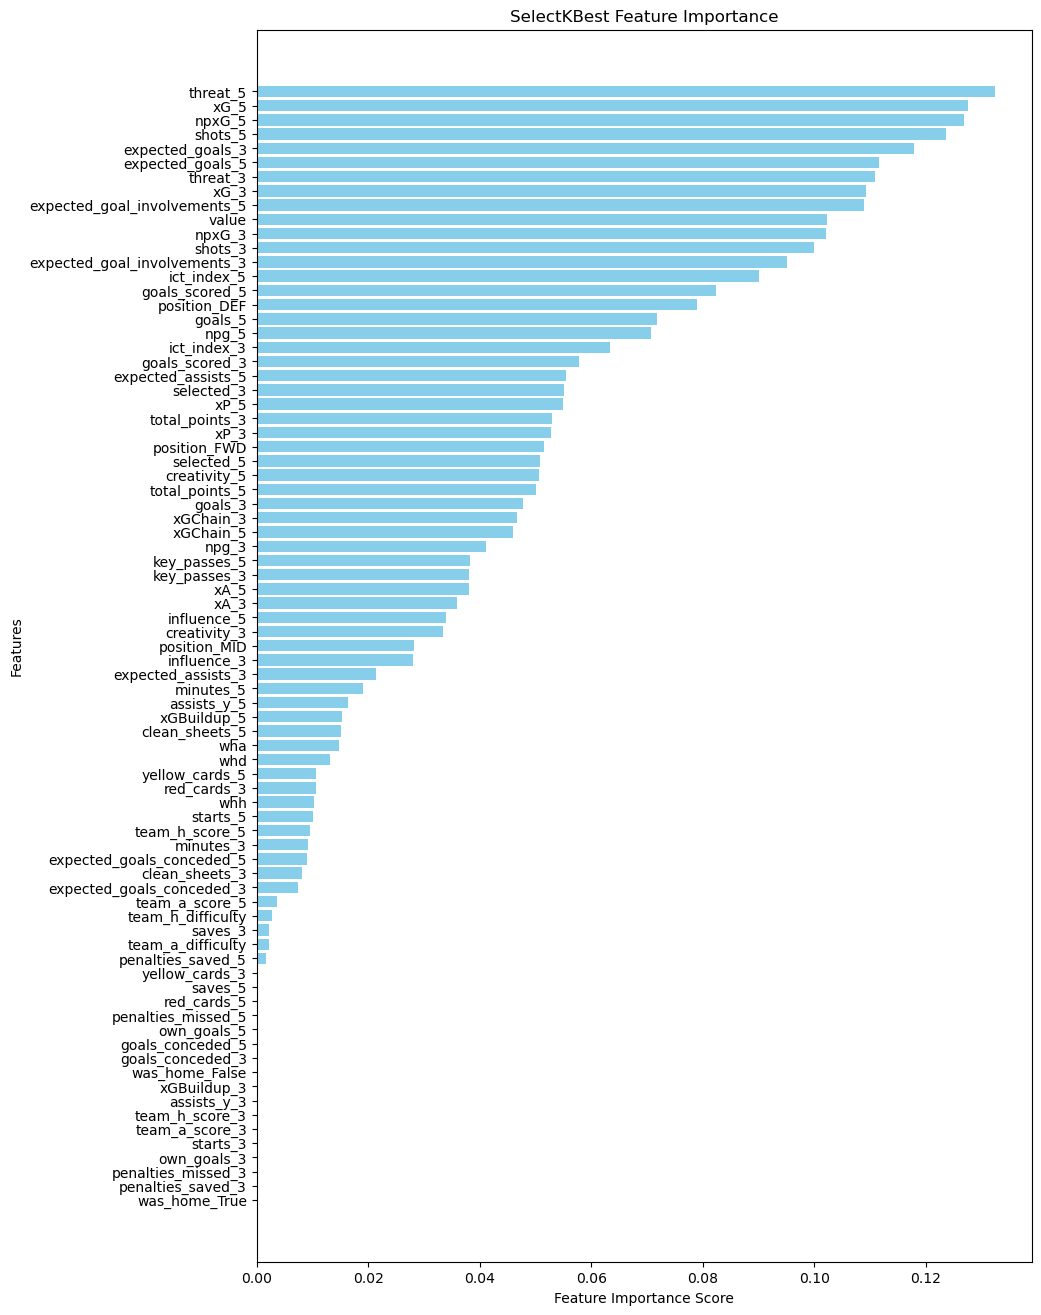

In [ ]:
# Get feature scores and names
feature_scores = selector.scores_  # Feature importance scores
feature_names = feats__.columns  # Feature names

# Sort features by importance
sorted_indices = np.argsort(feature_scores)[::-1]  # Sort descending
sorted_features = np.array(feature_names)[sorted_indices]
sorted_scores = feature_scores[sorted_indices]

# Plot feature importance
plt.figure(figsize=(10, 16))
plt.barh(sorted_features, sorted_scores, color='skyblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("SelectKBest Feature Importance")
plt.gca().invert_yaxis()  # Show most important feature on top
plt.show()

### Linear Model


In [ ]:

lin_reg_KBest = Linear_regression(feats_train_KBest, feats_test_KBest, xa_train_KBest.values.ravel(), xa_test_KBest.values.ravel())


# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(lin_reg_KBest = [lin_reg_KBest['train_MAE'], lin_reg_KBest['test_MAE'], lin_reg_KBest['train_RMSE'], lin_reg_KBest['test_RMSE'], lin_reg_KBest['cv_rmse'], lin_reg_KBest['R2_train'], lin_reg_KBest['R2_test']])

evaluation_stats

Training set RMSE: 0.9017448123189532
Test set RMSE: 0.8907777711538661
Training set R2: 0.19910354226008842
Test set R2: 0.15472562283115476


,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest
train_MAE,0.145041,0.000000,0.126302,0.137663,0.137663,0.545233,3.364884e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287,0.490059,0.538854
test_MAE,0.146444,0.185907,0.148974,0.146010,0.146010,0.534540,6.638842e-01,0.514367,0.514809,0.512716,0.518336,6.641633e-01,0.513976,0.511281,0.527282
train_RMSE,0.243127,0.000000,0.202660,0.226148,0.226148,0.905627,6.467355e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580,0.801809,0.901745
test_RMSE,0.251520,0.344034,0.255228,0.249178,0.249178,0.898854,1.223763e+00,0.878753,0.868901,0.867860,0.878322,1.230162e+00,0.879595,0.864707,0.890778
cv_rmse,0.244350,0.354079,0.247742,0.244522,0.244522,0.906434,1.273533e+00,0.891802,0.882911,0.888489,0.882367,1.284281e+00,0.893179,0.879937,0.903565
R2_train,0.227836,1.000000,0.463486,0.331917,0.331917,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657,0.366786,0.199104
R2_test,0.200059,-0.496630,0.176301,0.214886,0.214886,0.139329,-5.953403e-01,0.177393,0.195735,0.197661,0.178200,-6.120692e-01,0.175816,0.203479,0.154726


### Decision Tree


In [ ]:
dt_reg_KBest = DecisionTreeRegression(feats_train_KBest, feats_test_KBest, xa_train_KBest.values.ravel(), xa_test_KBest.values.ravel())

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(dt_reg_KBest = [dt_reg_KBest['train_MAE'], dt_reg_KBest['test_MAE'], dt_reg_KBest['train_RMSE'], dt_reg_KBest['test_RMSE'], dt_reg_KBest['cv_rmse'], dt_reg_KBest['R2_train'], dt_reg_KBest['R2_test']])

evaluation_stats



,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest,dt_reg_KBest
train_MAE,0.145041,0.000000,0.126302,0.137663,0.137663,0.545233,3.364884e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287,0.490059,0.538854,0.026063
test_MAE,0.146444,0.185907,0.148974,0.146010,0.146010,0.534540,6.638842e-01,0.514367,0.514809,0.512716,0.518336,6.641633e-01,0.513976,0.511281,0.527282,0.724221
train_RMSE,0.243127,0.000000,0.202660,0.226148,0.226148,0.905627,6.467355e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580,0.801809,0.901745,0.160176
test_RMSE,0.251520,0.344034,0.255228,0.249178,0.249178,0.898854,1.223763e+00,0.878753,0.868901,0.867860,0.878322,1.230162e+00,0.879595,0.864707,0.890778,1.313899
cv_rmse,0.244350,0.354079,0.247742,0.244522,0.244522,0.906434,1.273533e+00,0.891802,0.882911,0.888489,0.882367,1.284281e+00,0.893179,0.879937,0.903565,1.301972
R2_train,0.227836,1.000000,0.463486,0.331917,0.331917,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657,0.366786,0.199104,0.974730
R2_test,0.200059,-0.496630,0.176301,0.214886,0.214886,0.139329,-5.953403e-01,0.177393,0.195735,0.197661,0.178200,-6.120692e-01,0.175816,0.203479,0.154726,-0.839006


### RandomForest


In [ ]:
hyperparameters = {"criterion": 'friedman_mse', "max_depth": 8, "max_features": 'sqrt', "n_estimators": 20}
rf_reg_KBest = RandomForestRegression(feats_train_KBest, feats_test_KBest, xa_train_KBest.values.ravel(), xa_test_KBest.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(rf_reg_KBest = [rf_reg_KBest['train_MAE'], rf_reg_KBest['test_MAE'], rf_reg_KBest['train_RMSE'], rf_reg_KBest['test_RMSE'], rf_reg_KBest['cv_rmse'], rf_reg_KBest['R2_train'], rf_reg_KBest['R2_test']])

evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest,dt_reg_KBest,rf_reg_KBest
train_MAE,0.145041,0.000000,0.126302,0.137663,0.137663,0.545233,3.364884e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287,0.490059,0.538854,0.026063,0.477503
test_MAE,0.146444,0.185907,0.148974,0.146010,0.146010,0.534540,6.638842e-01,0.514367,0.514809,0.512716,0.518336,6.641633e-01,0.513976,0.511281,0.527282,0.724221,0.531881
train_RMSE,0.243127,0.000000,0.202660,0.226148,0.226148,0.905627,6.467355e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580,0.801809,0.901745,0.160176,0.773973
test_RMSE,0.251520,0.344034,0.255228,0.249178,0.249178,0.898854,1.223763e+00,0.878753,0.868901,0.867860,0.878322,1.230162e+00,0.879595,0.864707,0.890778,1.313899,0.905295
cv_rmse,0.244350,0.354079,0.247742,0.244522,0.244522,0.906434,1.273533e+00,0.891802,0.882911,0.888489,0.882367,1.284281e+00,0.893179,0.879937,0.903565,1.301972,0.919155
R2_train,0.227836,1.000000,0.463486,0.331917,0.331917,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657,0.366786,0.199104,0.974730,0.409988
R2_test,0.200059,-0.496630,0.176301,0.214886,0.214886,0.139329,-5.953403e-01,0.177393,0.195735,0.197661,0.178200,-6.120692e-01,0.175816,0.203479,0.154726,-0.839006,0.126950


### XgBoost


In [ ]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
xgb_reg_KBest = XGBoostRegression(feats_train_KBest, feats_test_KBest, xa_train_KBest.values.ravel(), xa_test_KBest.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(xgb_reg_KBest = [xgb_reg_KBest['train_MAE'], xgb_reg_KBest['test_MAE'], xgb_reg_KBest['train_RMSE'], xgb_reg_KBest['test_RMSE'], xgb_reg_KBest['cv_rmse'], xgb_reg_KBest['R2_train'], xgb_reg_KBest['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest,dt_reg_KBest,rf_reg_KBest,xgb_reg_KBest
train_MAE,0.145041,0.000000,0.126302,0.137663,0.137663,0.545233,3.364884e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287,0.490059,0.538854,0.026063,0.477503,0.522146
test_MAE,0.146444,0.185907,0.148974,0.146010,0.146010,0.534540,6.638842e-01,0.514367,0.514809,0.512716,0.518336,6.641633e-01,0.513976,0.511281,0.527282,0.724221,0.531881,0.531596
train_RMSE,0.243127,0.000000,0.202660,0.226148,0.226148,0.905627,6.467355e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580,0.801809,0.901745,0.160176,0.773973,0.861290
test_RMSE,0.251520,0.344034,0.255228,0.249178,0.249178,0.898854,1.223763e+00,0.878753,0.868901,0.867860,0.878322,1.230162e+00,0.879595,0.864707,0.890778,1.313899,0.905295,0.893056
cv_rmse,0.244350,0.354079,0.247742,0.244522,0.244522,0.906434,1.273533e+00,0.891802,0.882911,0.888489,0.882367,1.284281e+00,0.893179,0.879937,0.903565,1.301972,0.919155,0.905297
R2_train,0.227836,1.000000,0.463486,0.331917,0.331917,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657,0.366786,0.199104,0.974730,0.409988,0.269352
R2_test,0.200059,-0.496630,0.176301,0.214886,0.214886,0.139329,-5.953403e-01,0.177393,0.195735,0.197661,0.178200,-6.120692e-01,0.175816,0.203479,0.154726,-0.839006,0.126950,0.150396


### AdaBoost


In [ ]:
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
ada_reg_KBest = XGBoostRegression(feats_train_KBest, feats_test_KBest, xa_train_KBest.values.ravel(), xa_test_KBest.values.ravel(), hyperparameters)

# Store the model evaluation details in a DataFrame
evaluation_stats = evaluation_stats.assign(ada_reg_KBest = [ada_reg_KBest['train_MAE'], ada_reg_KBest['test_MAE'], ada_reg_KBest['train_RMSE'], ada_reg_KBest['test_RMSE'], ada_reg_KBest['cv_rmse'], ada_reg_KBest['R2_train'], ada_reg_KBest['R2_test']])
evaluation_stats

,lin_reg,dt_reg,rf_reg,xgb_reg,ada_reg,lin_reg_SFM,dt_reg_SFM,rf_reg_SFM,xgb_reg_SFM,ada_reg_SFM,VarT_lin_reg,VarT_dt_reg,VarT_rf_reg,VarT_xgb_reg,lin_reg_KBest,dt_reg_KBest,rf_reg_KBest,xgb_reg_KBest,ada_reg_KBest
train_MAE,0.145041,0.000000,0.126302,0.137663,0.137663,0.545233,3.364884e-17,0.447282,0.494053,0.498303,0.518709,6.693219e-19,0.446287,0.490059,0.538854,0.026063,0.477503,0.522146,0.522146
test_MAE,0.146444,0.185907,0.148974,0.146010,0.146010,0.534540,6.638842e-01,0.514367,0.514809,0.512716,0.518336,6.641633e-01,0.513976,0.511281,0.527282,0.724221,0.531881,0.531596,0.531596
train_RMSE,0.243127,0.000000,0.202660,0.226148,0.226148,0.905627,6.467355e-17,0.718174,0.810789,0.816534,0.870151,1.397837e-17,0.715580,0.801809,0.901745,0.160176,0.773973,0.861290,0.861290
test_RMSE,0.251520,0.344034,0.255228,0.249178,0.249178,0.898854,1.223763e+00,0.878753,0.868901,0.867860,0.878322,1.230162e+00,0.879595,0.864707,0.890778,1.313899,0.905295,0.893056,0.893056
cv_rmse,0.244350,0.354079,0.247742,0.244522,0.244522,0.906434,1.273533e+00,0.891802,0.882911,0.888489,0.882367,1.284281e+00,0.893179,0.879937,0.903565,1.301972,0.919155,0.905297,0.905297
R2_train,0.227836,1.000000,0.463486,0.331917,0.331917,0.192193,1.000000e+00,0.491994,0.352522,0.343314,0.254241,1.000000e+00,0.495657,0.366786,0.199104,0.974730,0.409988,0.269352,0.269352
R2_test,0.200059,-0.496630,0.176301,0.214886,0.214886,0.139329,-5.953403e-01,0.177393,0.195735,0.197661,0.178200,-6.120692e-01,0.175816,0.203479,0.154726,-0.839006,0.126950,0.150396,0.150396


# Hyperparameter Tunning

Picked XGBoost


In [ ]:

from sklearn.model_selection import RandomizedSearchCV

# Define XGBoost model
xgb_model = xgb(objective='reg:squarederror', random_state=42)

# Define hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5, 1.0],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [0, 0.01, 0.1, 1, 10]
}

# Perform Randomized Search
random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_dist,
    n_iter=50, scoring='neg_mean_absolute_error',
    cv=5, verbose=2, random_state=42, n_jobs=-1
)

# Fit to training data
random_search.fit(feats_sklearn_enc_scaled, xg.values.ravel())

# Best parameters
print("Best Parameters:", random_search.best_params_)

# Best model
best_xgb = random_search.best_estimator_


Fitting 5 folds for each of 50 candidates, totalling 250 fits
